# Cross-encoder aligner evaluation: all four aligners x three sample sizes x two teachers

Evaluates the four ModernBERT CrossEncoder aligners (schedule, activity,
vehicle-ownership, profile-coherence) trained by `scripts/run_cross_encoder_eval.py`
at sample sizes 100 / 1000 / 10000, each with an 80/20 stratified train/test split,
labeled by both the Qwen and Mistral teachers served at the same sibling endpoint.

This notebook only loads and reports the results the driver script already computed
(`data/eval/cross_encoders/results.parquet`, the resumable epoch sweep, and per-combo
prediction parquets) — it does not itself run labeling or training, since that sweep can
take hours. See
`notebooks/06_cross_reranker_evaluation/01_profile_coherence_evaluation.ipynb` for
the original single-aligner evaluation this one supersedes in scope (all four
aligners, all three sample sizes, both teachers) but not in per-example diagnostics.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
if not (repo_root / 'pyproject.toml').exists():
    raise FileNotFoundError('Run this notebook from inside the citybehavex repository.')

DATA_ROOT = repo_root / 'data/eval/cross_encoders'
RESULTS_PATH = DATA_ROOT / 'results.parquet'
EPOCH_SWEEP_PATH = DATA_ROOT / 'epoch_sweep_mistral.parquet'
OUTPUT_DIR = repo_root / 'notebooks/06_cross_reranker_evaluation/outputs/multi_aligner'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ALIGNERS = ['schedule', 'activity', 'vehicle_ownership', 'profile_coherence']
SAMPLE_SIZES = [100, 1000, 10000]
TEACHERS = ['qwen', 'mistral']
PLOT_EPOCHS = [1, 5, 10]


## Coverage: which (aligner, teacher, sample_size) combos are done

In [2]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f'{RESULTS_PATH} does not exist yet. Run scripts/run_cross_encoder_eval.py first '
        '(once per teacher currently served at the sibling endpoint).'
    )

results = pd.read_parquet(RESULTS_PATH).copy()
# The original sample-size sweep trained for one epoch. The epoch sweep uses
# identical cached Mistral labels and splits at n=100/1000, and supersedes its
# epoch-1 rows so every plotted epoch comes from the same runner/environment.
results['epochs'] = 1
if EPOCH_SWEEP_PATH.exists():
    epoch_results = pd.read_parquet(EPOCH_SWEEP_PATH)
    replaced = (
        results['teacher'].eq('mistral')
        & results['sample_size'].isin(epoch_results['sample_size'].unique())
        & results['aligner'].isin(epoch_results['aligner'].unique())
    )
    results = pd.concat([results.loc[~replaced], epoch_results], ignore_index=True, sort=False)
    print(f'Loaded {len(epoch_results)} epoch-sweep rows from {EPOCH_SWEEP_PATH.name}.')
else:
    print(f'Epoch sweep not found at {EPOCH_SWEEP_PATH}; showing epoch-1 results only.')
print(f'Loaded {len(results)} combined result rows.')

coverage = pd.DataFrame(
    index=pd.MultiIndex.from_product([ALIGNERS, SAMPLE_SIZES], names=['aligner', 'sample_size']),
    columns=TEACHERS,
).fillna(False)
for _, row in results.iterrows():
    if row['aligner'] in ALIGNERS and row['teacher'] in TEACHERS and row['sample_size'] in SAMPLE_SIZES:
        coverage.loc[(row['aligner'], row['sample_size']), row['teacher']] = True
display(coverage)

missing = coverage[~coverage.all(axis=1)]
if len(missing):
    print(f'{len(missing)} combo(s) not yet complete for both teachers:')
    display(missing)
else:
    print('All aligner x sample_size x teacher combos are present for both teachers.')


Loaded 80 epoch-sweep rows from epoch_sweep_mistral.parquet.
Loaded 84 combined result rows.


qwen mistral
aligner           sample_size               
schedule          100          False    True
                  1000         False    True
                  10000        False    True
activity          100          False    True
                  1000         False    True
                  10000        False    True
vehicle_ownership 100          False    True
                  1000         False    True
                  10000        False    True
profile_coherence 100          False    True
                  1000         False    True
                  10000        False    True

12 combo(s) not yet complete for both teachers:


qwen mistral
aligner           sample_size               
schedule          100          False    True
                  1000         False    True
                  10000        False    True
activity          100          False    True
                  1000         False    True
                  10000        False    True
vehicle_ownership 100          False    True
                  1000         False    True
                  10000        False    True
profile_coherence 100          False    True
                  1000         False    True
                  10000        False    True

## Per-aligner metric comparison across sample sizes and teachers

Common metrics for every aligner: MAE, RMSE, Spearman and Kendall-tau correlation with
the teacher score, and 10-bin calibration MAE. `n_train`/`n_test` confirm the 80/20 split.

In [3]:
METRIC_COLS = ['n_train', 'n_test', 'mae', 'rmse', 'spearman', 'kendall_tau', 'calibration_mae']

def aligner_table(aligner):
    subset = results[results['aligner'] == aligner]
    if subset.empty:
        print(f'No results yet for {aligner}.')
        return None
    table = (
        subset.set_index(['sample_size', 'teacher', 'epochs'])[METRIC_COLS]
        .sort_index()
    )
    return table

aligner_tables = {}
for aligner in ALIGNERS:
    print(f'### {aligner}')
    table = aligner_table(aligner)
    aligner_tables[aligner] = table
    if table is not None:
        display(table)


### schedule


n_train  n_test       mae      rmse  spearman  \
sample_size teacher epochs                                                  
100         mistral 1            80      20  0.168208  0.215716  0.564562   
                    2            80      20  0.129220  0.191728  0.557621   
                    3            80      20  0.126139  0.184895  0.552222   
                    4            80      20  0.113846  0.193575  0.581530   
                    5            80      20  0.121014  0.195688  0.622407   
                    6            80      20  0.109129  0.190726  0.668682   
                    7            80      20  0.144735  0.201845  0.598498   
                    8            80      20  0.105646  0.179349  0.644002   
                    9            80      20  0.106555  0.175750  0.610066   
                    10           80      20  0.104044  0.176864  0.660198   
1000        mistral 1           800     200  0.081294  0.105773  0.777287   
                    2           800     200  0.073886  0.097766  0.789873   
                    3           800     200  0.072570  0.093262  0.815637   
                    4           800     200  0.067695  0.090185  0.822169   
                    5           800     200  0.064597  0.089351  0.823497   
                    6           800     200  0.063618  0.084787  0.834118   
                    7           800     200  0.063496  0.085485  0.830249   
                    8           800     200  0.064631  0.086813  0.812751   
                    9           800     200  0.067477  0.089995  0.799943   
                    10          800     200  0.066854  0.091478  0.799648   
10000       mistral 1          8000    2000  0.064046  0.089638  0.856397   

                            kendall_tau  calibration_mae  
sample_size teacher epochs                                
100         mistral 1          0.415554         0.133386  
                    2          0.392467         0.078289  
                    3          0.380924         0.085596  
                    4          0.415554         0.076317  
                    5          0.519442         0.097432  
                    6          0.519442         0.090229  
                    7          0.438640         0.098696  
                    8          0.519442         0.046734  
                    9          0.450183         0.067515  
                    10         0.507899         0.073721  
1000        mistral 1          0.630722         0.031670  
                    2          0.641805         0.023321  
                    3          0.673710         0.025329  
                    4          0.677852         0.015331  
                    5          0.683786         0.007845  
                    6          0.693637         0.008874  
                    7          0.689271         0.007263  
                    8          0.669120         0.008965  
                    9          0.656246         0.006769  
                    10         0.657142         0.019270  
10000       mistral 1          0.717608         0.007789

### activity


n_train  n_test       mae      rmse  spearman  \
sample_size teacher epochs                                                  
100         mistral 1            80      20  0.274643  0.307465  0.110657   
                    2            80      20  0.305378  0.396986  0.277787   
                    3            80      20  0.241643  0.299631  0.271682   
                    4            80      20  0.255740  0.311957  0.029000   
                    5            80      20  0.204804  0.267905  0.408286   
                    6            80      20  0.222258  0.274719  0.321287   
                    7            80      20  0.177919  0.236733  0.476207   
                    8            80      20  0.187563  0.242534  0.492233   
                    9            80      20  0.191772  0.246348  0.492233   
                    10           80      20  0.228705  0.279596  0.372418   
1000        mistral 1           800     200  0.132790  0.203283  0.658563   
                    2           800     200  0.128505  0.198654  0.712563   
                    3           800     200  0.130815  0.190917  0.696161   
                    4           800     200  0.123413  0.196964  0.697930   
                    5           800     200  0.117190  0.176951  0.761278   
                    6           800     200  0.109141  0.176643  0.775689   
                    7           800     200  0.116718  0.176168  0.766038   
                    8           800     200  0.106301  0.165400  0.789970   
                    9           800     200  0.092579  0.149604  0.825920   
                    10          800     200  0.093894  0.148918  0.825534   
10000       mistral 1          8000    2000  0.083651  0.133233  0.847239   

                            kendall_tau  calibration_mae  
sample_size teacher epochs                                
100         mistral 1          0.072981         0.129361  
                    2          0.196487         0.279633  
                    3          0.185259         0.138091  
                    4          0.039297         0.180543  
                    5          0.308765         0.150580  
                    6          0.252626         0.079292  
                    7          0.364904         0.117003  
                    8          0.376132         0.108820  
                    9          0.364904         0.093579  
                    10         0.252626         0.166624  
1000        mistral 1          0.528337         0.058719  
                    2          0.574299         0.053141  
                    3          0.569714         0.049038  
                    4          0.576088         0.059279  
                    5          0.624398         0.045265  
                    6          0.637035         0.038172  
                    7          0.623839         0.032860  
                    8          0.643633         0.046413  
                    9          0.688923         0.036025  
                    10         0.686240         0.035687  
10000       mistral 1          0.715995         0.015302

### vehicle_ownership


n_train  n_test       mae      rmse  spearman  \
sample_size teacher epochs                                                  
100         mistral 1            80      20  0.121862  0.152212  0.348642   
                    2            80      20  0.153513  0.183017  0.586604   
                    3            80      20  0.130968  0.149554  0.323344   
                    4            80      20  0.092834  0.120148  0.633248   
                    5            80      20  0.073480  0.100117  0.806383   
                    6            80      20  0.105438  0.132937  0.528102   
                    7            80      20  0.060962  0.081933  0.784247   
                    8            80      20  0.089306  0.109380  0.763692   
                    9            80      20  0.068193  0.092093  0.806383   
                    10           80      20  0.091026  0.116183  0.652222   
1000        mistral 1           800     200  0.086083  0.107327  0.710141   
                    2           800     200  0.073994  0.095553  0.779652   
                    3           800     200  0.071848  0.091125  0.789485   
                    4           800     200  0.067796  0.085527  0.809252   
                    5           800     200  0.062115  0.079626  0.834832   
                    6           800     200  0.066742  0.084049  0.815378   
                    7           800     200  0.060772  0.079093  0.847179   
                    8           800     200  0.054647  0.072311  0.873574   
                    9           800     200  0.052250  0.069132  0.878897   
                    10          800     200  0.048439  0.069218  0.884699   
10000       mistral 1          8000    2000  0.055054  0.070142  0.881093   

                            kendall_tau  calibration_mae  
sample_size teacher epochs                                
100         mistral 1          0.262389         0.080420  
                    2          0.488997         0.137469  
                    3          0.250462         0.070993  
                    4          0.477070         0.034050  
                    5          0.655972         0.066825  
                    6          0.381656         0.026441  
                    7          0.644045         0.047914  
                    8          0.596338         0.066211  
                    9          0.655972         0.045678  
                    10         0.477070         0.030124  
1000        mistral 1          0.560922         0.017397  
                    2          0.632522         0.025447  
                    3          0.643951         0.015708  
                    4          0.669723         0.011801  
                    5          0.701545         0.012260  
                    6          0.674989         0.013751  
                    7          0.718689         0.021457  
                    8          0.750735         0.016957  
                    9          0.755329         0.009184  
                    10         0.766982         0.015464  
10000       mistral 1          0.751716         0.011594

### profile_coherence


n_train  n_test       mae      rmse  spearman  \
sample_size teacher epochs                                                  
100         mistral 1            80      20  0.296422  0.307616  0.708896   
                    2            80      20  0.221550  0.244584  0.719625   
                    3            80      20  0.127938  0.175254  0.867346   
                    4            80      20  0.141483  0.200046  0.817005   
                    5            80      20  0.154925  0.225118  0.605739   
                    6            80      20  0.123909  0.190179  0.739431   
                    7            80      20  0.119899  0.180803  0.788121   
                    8            80      20  0.126442  0.210023  0.724576   
                    9            80      20  0.125782  0.202552  0.791422   
                    10           80      20  0.162199  0.233560  0.700644   
1000        mistral 1           800     200  0.085948  0.123554  0.873531   
                    2           800     200  0.077357  0.132286  0.867658   
                    3           800     200  0.068652  0.110095  0.877589   
                    4           800     200  0.054318  0.087429  0.898369   
                    5           800     200  0.050798  0.083856  0.904589   
                    6           800     200  0.042302  0.069981  0.916292   
                    7           800     200  0.043563  0.076075  0.913722   
                    8           800     200  0.039910  0.073797  0.921586   
                    9           800     200  0.037006  0.067596  0.919604   
                    10          800     200  0.036117  0.069654  0.923030   
10000       mistral 1          8000    2000  0.034030  0.060858  0.921045   

                            kendall_tau  calibration_mae  
sample_size teacher epochs                                
100         mistral 1          0.534479         0.149053  
                    2          0.598108         0.126845  
                    3          0.738090         0.046903  
                    4          0.687188         0.091997  
                    5          0.483576         0.131954  
                    6          0.598108         0.100257  
                    7          0.649010         0.091034  
                    8          0.585382         0.077238  
                    9          0.649010         0.106854  
                    10         0.559931         0.107285  
1000        mistral 1          0.720998         0.037916  
                    2          0.713460         0.030471  
                    3          0.731246         0.033377  
                    4          0.764817         0.024018  
                    5          0.776831         0.015994  
                    6          0.796385         0.013802  
                    7          0.789690         0.021904  
                    8          0.804630         0.014690  
                    9          0.805454         0.009233  
                    10         0.810755         0.017322  
10000       mistral 1          0.810290         0.006106

## Plots: MAE and Spearman vs. sample size

Each aligner/model has its own color; teacher is encoded by marker, and epoch count by
line style: solid for 1 epoch, dashed for 5, and dotted for 10. The epoch sweep currently
covers Mistral at n=100 and n=1000; a line is drawn only where results are available.


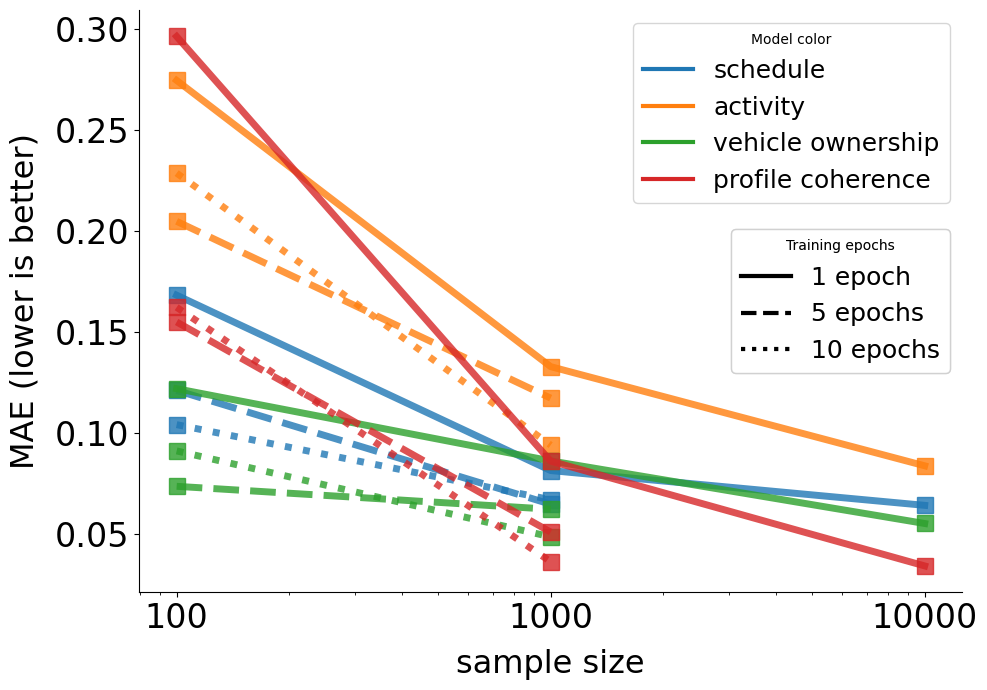

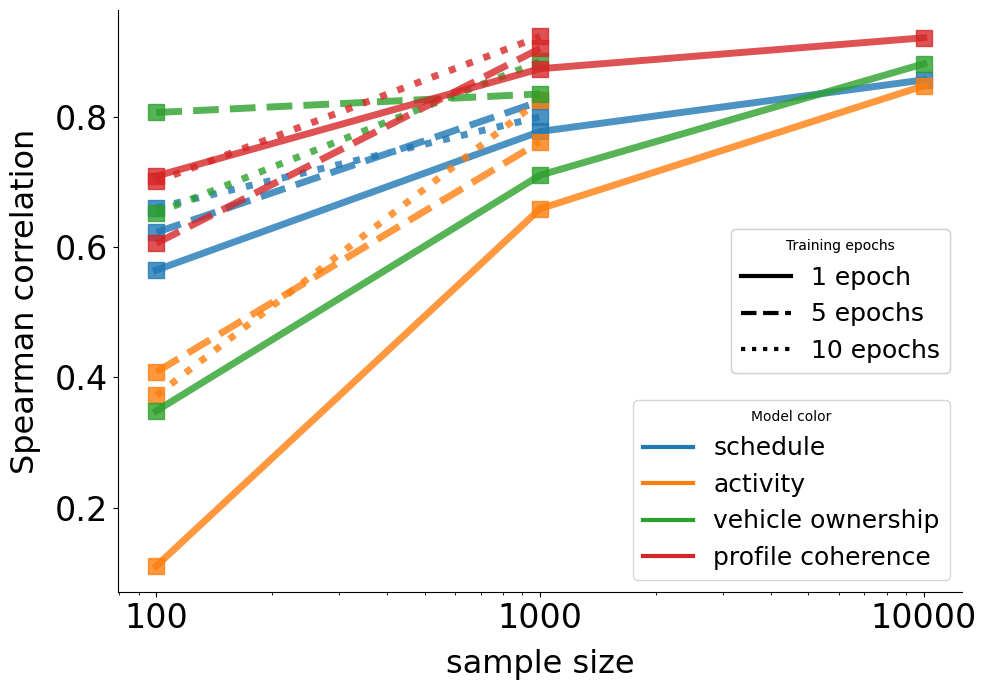

In [4]:
from matplotlib.lines import Line2D

MODEL_COLORS = dict(zip(ALIGNERS, plt.rcParams['axes.prop_cycle'].by_key()['color']))
TEACHER_MARKERS = dict(zip(TEACHERS, ['o', 's']))
EPOCH_STYLES = {1: '-', 5: '--', 10: ':'}

def plot_metric_vs_size(metric, ylabel):
    fig, ax = plt.subplots(figsize=(10, 7))
    for aligner in ALIGNERS:
        subset = results[results['aligner'] == aligner]
        for teacher in TEACHERS:
            for epochs in PLOT_EPOCHS:
                rows = subset[(subset['teacher'] == teacher) & (subset['epochs'] == epochs)]
                rows = rows.sort_values('sample_size')
                if rows.empty:
                    continue
                ax.plot(
                    rows['sample_size'], rows[metric], marker=TEACHER_MARKERS[teacher],
                    color=MODEL_COLORS[aligner], linestyle=EPOCH_STYLES[epochs],
                    linewidth=5, markersize=12, alpha=0.8
                )

    ax.set_xscale('log')
    ax.set_xticks(SAMPLE_SIZES)
    ax.set_xticklabels(SAMPLE_SIZES)
    ax.set_ylabel(ylabel, fontsize=23, labelpad=10)
    ax.set_xlabel('sample size', fontsize=23, labelpad=10)
    ax.tick_params(axis='both', which='major', labelsize=24)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    color_handles = [
        Line2D([0], [0], color=MODEL_COLORS[aligner], lw=3, label=aligner.replace('_', ' '))
        for aligner in ALIGNERS
    ]
    epoch_handles = [
        Line2D([0], [0], color='black', lw=3, linestyle=EPOCH_STYLES[epochs],
               label=f'{epochs} epoch' + ('' if epochs == 1 else 's'))
        for epochs in PLOT_EPOCHS
    ]
    teacher_handles = [
        Line2D([0], [0], color='black', marker=TEACHER_MARKERS[teacher], linestyle='None',
               markersize=9, label=teacher)
        for teacher in TEACHERS
    ]
    color_legend = ax.legend(handles=color_handles, title='Model color', loc='best', fontsize=18)
    ax.add_artist(color_legend)
    epoch_legend = ax.legend(handles=epoch_handles, title='Training epochs', loc='center right', fontsize=18)
    ax.add_artist(epoch_legend)
    # ax.legend(handles=teacher_handles, title='Teacher marker', loc='lower right', fontsize=18)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'alignment_{metric}_vs_sample_size.pdf', dpi=150, bbox_inches='tight')
    plt.show()

plot_metric_vs_size('mae', 'MAE (lower is better)')
plot_metric_vs_size('spearman', 'Spearman correlation')

## Aligner-specific extras

Profile-coherence: ROC-AUC/PR-AUC separating original vs. mutated profiles, and the
fraction of profiles where the model correctly ranks the original above its mutated
variant. Schedule/activity/vehicle-ownership: per-category MAE breakdown (day_type,
purpose, vehicle respectively) stored as a JSON string per result row.

In [5]:
coherence_extra_cols = ['original_vs_mutated_roc_auc', 'original_vs_mutated_pr_auc', 'paired_original_beats_mutated']
coherence_rows = results[results['aligner'] == 'profile_coherence']
if not coherence_rows.empty:
    display(coherence_rows.set_index(['sample_size', 'teacher', 'epochs'])[coherence_extra_cols].sort_index())

breakdown_cols = {
    'schedule': 'day_type_mae_breakdown',
    'activity': 'purpose_mae_breakdown',
    'vehicle_ownership': 'vehicle_mae_breakdown',
}
for aligner, col in breakdown_cols.items():
    subset = results[results['aligner'] == aligner]
    if subset.empty or col not in subset.columns:
        continue
    print(f'### {aligner}: {col}')
    for _, row in subset.sort_values(['teacher', 'sample_size', 'epochs']).iterrows():
        if pd.isna(row.get(col)):
            continue
        breakdown = json.loads(row[col])
        print(f"  teacher={row['teacher']} n={row['sample_size']} epochs={row['epochs']}: {breakdown}")


original_vs_mutated_roc_auc  \
sample_size teacher epochs                                
100         mistral 1                          0.737374   
                    2                          0.838384   
                    3                          0.878788   
                    4                          0.828283   
                    5                          0.858586   
                    6                          0.858586   
                    7                          0.909091   
                    8                          0.898990   
                    9                          0.888889   
                    10                         0.888889   
1000        mistral 1                          0.987079   
                    2                          0.988482   
                    3                          0.983474   
                    4                          0.982272   
                    5                          0.978966   
                    6                          0.977464   
                    7                          0.979267   
                    8                          0.975661   
                    9                          0.979968   
                    10                         0.971054   
10000       mistral 1                          0.965024   

                            original_vs_mutated_pr_auc  \
sample_size teacher epochs                               
100         mistral 1                         0.775926   
                    2                         0.883895   
                    3                         0.907937   
                    4                         0.889669   
                    5                         0.899537   
                    6                         0.904483   
                    7                         0.929167   
                    8                         0.921086   
                    9                         0.917409   
                    10                        0.904630   
1000        mistral 1                         0.990526   
                    2                         0.992411   
                    3                         0.988631   
                    4                         0.986164   
                    5                         0.983786   
                    6                         0.981575   
                    7                         0.983724   
                    8                         0.981381   
                    9                         0.981816   
                    10                        0.977580   
10000       mistral 1                         0.968180   

                            paired_original_beats_mutated  
sample_size teacher epochs                                 
100         mistral 1                            1.000000  
                    2                            1.000000  
                    3                            1.000000  
                    4                            1.000000  
                    5                            1.000000  
                    6                            1.000000  
                    7                            1.000000  
                    8                            1.000000  
                    9                            1.000000  
                    10                           1.000000  
1000        mistral 1                            1.000000  
                    2                            1.000000  
                    3                            1.000000  
                    4                            1.000000  
                    5                            1.000000  
                    6                            1.000000  
                    7                            1.000000  
                    8                            1.000000  
                    9                            1.000000  
                    10                           1.000000  
10000       mis

### schedule: day_type_mae_breakdown
  teacher=mistral n=100 epochs=1: {'weekday': 0.17907728523015976, 'weekend': 0.1573381578922272}
  teacher=mistral n=100 epochs=2: {'weekday': 0.14168375715613366, 'weekend': 0.11675581634044645}
  teacher=mistral n=100 epochs=3: {'weekday': 0.13294881626963617, 'weekend': 0.11932881593704223}
  teacher=mistral n=100 epochs=4: {'weekday': 0.14354910507798196, 'weekend': 0.08414303660392759}
  teacher=mistral n=100 epochs=5: {'weekday': 0.1416582602262497, 'weekend': 0.10036991655826566}
  teacher=mistral n=100 epochs=6: {'weekday': 0.135846286714077, 'weekend': 0.08241174101829526}
  teacher=mistral n=100 epochs=7: {'weekday': 0.1507514549791813, 'weekend': 0.1387188076972961}
  teacher=mistral n=100 epochs=8: {'weekday': 0.12815514847636222, 'weekend': 0.08313744664192198}
  teacher=mistral n=100 epochs=9: {'weekday': 0.12060925915837288, 'weekend': 0.09250067949295042}
  teacher=mistral n=100 epochs=10: {'weekday': 0.11908464416861535, 'weekend':

## Teacher agreement: Qwen vs. Mistral on the identical pairs

Both teachers label the exact same generated pairs (`build_training_pairs` depends only
on the seed, not the teacher), in the same row order, at the largest sample size
(10000). This compares the two teachers directly, independent of any trained model.

schedule: need both teachers labeled at n=10000 to compare (missing one or both).
activity: need both teachers labeled at n=10000 to compare (missing one or both).
vehicle_ownership: need both teachers labeled at n=10000 to compare (missing one or both).
profile_coherence: need both teachers labeled at n=10000 to compare (missing one or both).


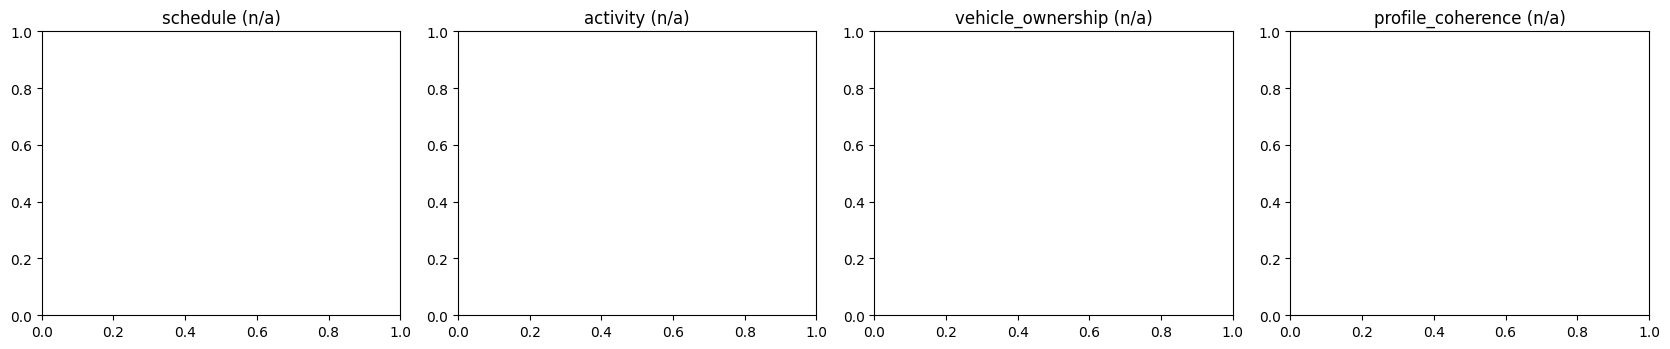

In [6]:
def teacher_agreement(aligner):
    qwen_path = DATA_ROOT / aligner / 'qwen_n10000.parquet'
    mistral_path = DATA_ROOT / aligner / 'mistral_n10000.parquet'
    if not (qwen_path.exists() and mistral_path.exists()):
        print(f'{aligner}: need both teachers labeled at n=10000 to compare (missing one or both).')
        return None
    qwen_df = pd.read_parquet(qwen_path)
    mistral_df = pd.read_parquet(mistral_path)
    if len(qwen_df) != len(mistral_df):
        print(f'{aligner}: row count mismatch ({len(qwen_df)} vs {len(mistral_df)}), skipping.')
        return None
    from scipy.stats import spearmanr
    from sklearn.metrics import mean_absolute_error
    agreement = {
        'n': len(qwen_df),
        'spearman': float(spearmanr(qwen_df['score'], mistral_df['score']).statistic),
        'mae': float(mean_absolute_error(qwen_df['score'], mistral_df['score'])),
    }
    return agreement, qwen_df['score'].to_numpy(), mistral_df['score'].to_numpy()

fig, axes = plt.subplots(1, len(ALIGNERS), figsize=(4.2 * len(ALIGNERS), 3.6))
agreement_rows = []
for ax, aligner in zip(axes, ALIGNERS):
    result = teacher_agreement(aligner)
    if result is None:
        ax.set_title(f'{aligner} (n/a)')
        continue
    agreement, qwen_scores, mistral_scores = result
    agreement['aligner'] = aligner
    agreement_rows.append(agreement)
    ax.scatter(qwen_scores, mistral_scores, alpha=0.25, s=10)
    ax.plot([0, 1], [0, 1], '--', color='black')
    ax.set_title(f"{aligner}\nspearman={agreement['spearman']:.3f}")
    ax.set_xlabel('Qwen score')
    ax.set_ylabel('Mistral score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'teacher_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

if agreement_rows:
    display(pd.DataFrame(agreement_rows).set_index('aligner'))


## Cross-aligner summary and save

In [7]:
summary = results[['aligner', 'teacher', 'sample_size', 'epochs'] + METRIC_COLS].sort_values(
    ['aligner', 'sample_size', 'teacher', 'epochs']
).reset_index(drop=True)
display(summary)
summary.to_csv(OUTPUT_DIR / 'summary_metrics.csv', index=False)
print(f'Saved summary to {OUTPUT_DIR / "summary_metrics.csv"}')


,aligner,teacher,sample_size,epochs,n_train,n_test,mae,rmse,spearman,kendall_tau,calibration_mae
0,activity,mistral,100,1,80,20,0.274643,0.307465,0.110657,0.072981,0.129361
1,activity,mistral,100,2,80,20,0.305378,0.396986,0.277787,0.196487,0.279633
2,activity,mistral,100,3,80,20,0.241643,0.299631,0.271682,0.185259,0.138091
3,activity,mistral,100,4,80,20,0.255740,0.311957,0.029000,0.039297,0.180543
4,activity,mistral,100,5,80,20,0.204804,0.267905,0.408286,0.308765,0.150580
...,...,...,...,...,...,...,...,...,...,...,...
79,vehicle_ownership,mistral,1000,7,800,200,0.060772,0.079093,0.847179,0.718689,0.021457
80,vehicle_ownership,mistral,1000,8,800,200,0.054647,0.072311,0.873574,0.750735,0.016957
81,vehicle_ownership,mistral,1000,9,800,200,0.052250,0.069132,0.878897,0.755329,0.009184
82,vehicle_ownership,mistral,1000,10,800,200,0.048439,0.069218,0.884699,0.766982,0.015464


Saved summary to /home/gustavo/citybehavex/notebooks/06_cross_reranker_evaluation/outputs/multi_aligner/summary_metrics.csv
